<a href="https://colab.research.google.com/github/fernanda0402/Doutorado/blob/main/Teste_de_f(z).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Bibliotecas:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp

In [2]:
!pip install -q condacolab
import condacolab
condacolab.install()
!mamba install pyccl

✨🍰✨ Everything looks OK!

Looking for: ['pyccl']

conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache

Pinned packages:
  - python 3.10.*
  - python 3.10.*
  - python_abi 3.10.* *cp310*
  - cuda-version 12.*


Transaction

  Prefix: /usr/local

  All requested packages already installed



In [3]:
import pyccl as ccl

In [4]:
cosmo = ccl.Cosmology(
    Omega_c=0.2656, Omega_b=0.0494, h=0.6727, sigma8=0.8120, n_s=0.9649)


a = np.linspace(0.33, 1, 1000)  # fator de escala
delta = ccl.growth_factor(cosmo, a)  # contraste

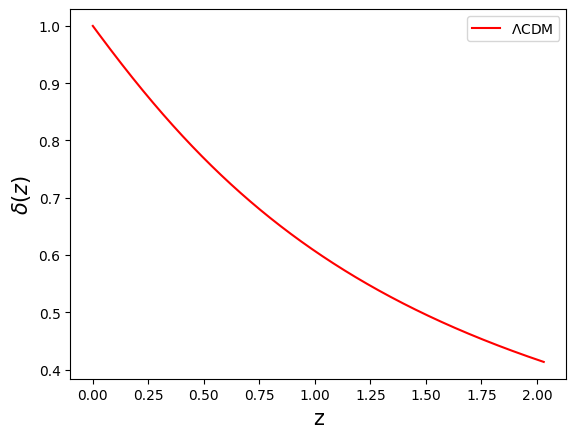

In [5]:
# definindo o redshift em função do fator de escala
z = (1/a) - 1.

# plotando o gráfico de delta x z

plt.xlabel('z', fontsize=15)
plt.ylabel('$\delta(z)$', fontsize=15)
plt.plot(z, delta, color='red', label='$\Lambda$CDM')
plt.legend()
plt.show()

Porém, $\delta_m$ não é um observável. Como queremos comparar os modelos alternativos com dados, precisamos da função $f$, defininda como:

$f(a) = \frac{d ln(\delta_m)}{d ln(a)}$.

Este parâmetro é um observável cosmológico e é chamado de função taxa de crescimento de estruturas.

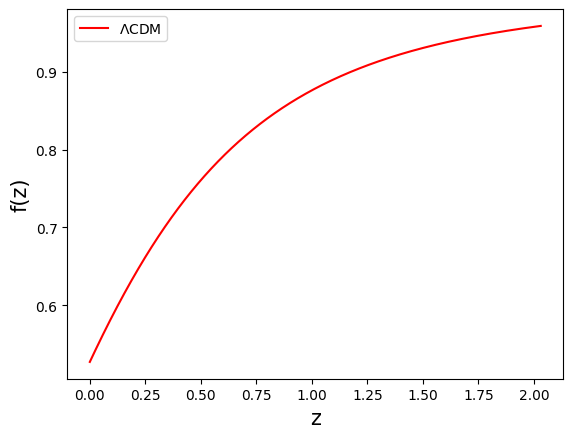

In [6]:
# definindo f com a biblioteca pyccl
f = ccl.background.growth_rate(cosmo, a)

# plotando f

plt.xlabel('z', fontsize=15)
plt.ylabel('f(z)', fontsize=15)
plt.plot(z, f, color='red', label='$\Lambda$CDM')
plt.legend()
plt.show()

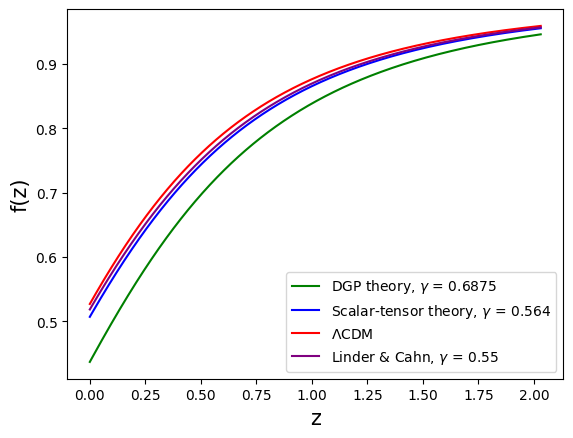

In [7]:
# constantes
H0 = 70 #km/s/Mpc
Om0 = 0.30

# definindo O_m
Om = (Om0*(a**(-3)))/(Om0*(a**(-3)) + 1 - Om0)

# DGP
gamma1 = 0.6875

f1 = Om ** gamma1

# teorias escalares-tensoriais
gamma2 = 0.564

f2 = Om ** gamma2


# linder e cahn
f3 = Om ** (6/11)

plt.plot(z, f1, color='green', label='DGP theory, $\gamma$ = 0.6875')
plt.plot(z, f2, color='blue', label='Scalar-tensor theory, $\gamma$ = 0.564')
plt.plot(z, f, color='red', label='$\Lambda$CDM')
plt.plot(z, f3, color='purple', label='Linder & Cahn, $\gamma$ = 0.55')
plt.xlabel('z', fontsize=15)
plt.ylabel('f(z)', fontsize=15)
plt.legend()
#plt.savefig('f theories.pdf')
plt.show()

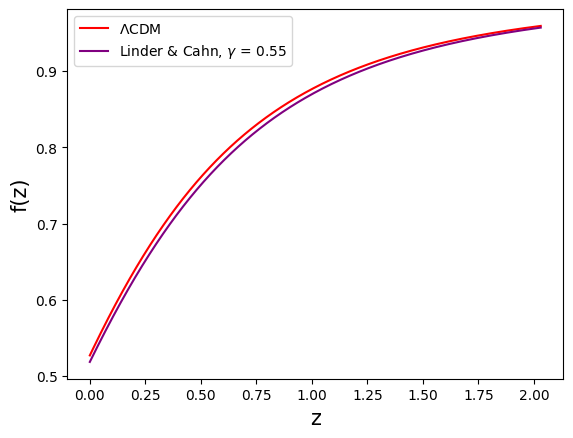

In [8]:
plt.plot(z, f, color='red', label='$\Lambda$CDM')
plt.plot(z, f3, color='purple', label='Linder & Cahn, $\gamma$ = 0.55')

plt.xlabel('z', fontsize=15)
plt.ylabel('f(z)', fontsize=15)
plt.legend()
#plt.savefig('f linder e lcdm.pdf')
plt.show()

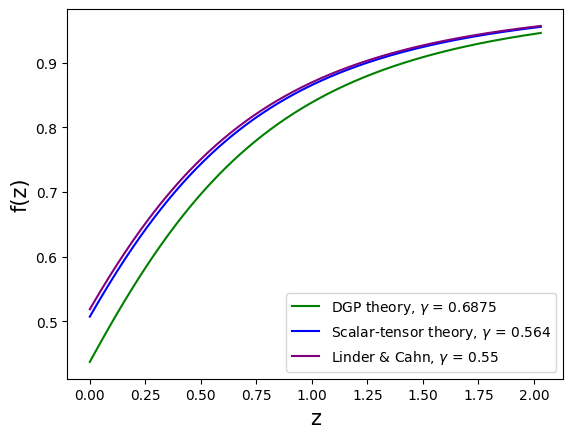

In [9]:
plt.plot(z, f1, color='green', label='DGP theory, $\gamma$ = 0.6875')
plt.plot(z, f2, color='blue', label='Scalar-tensor theory, $\gamma$ = 0.564')
plt.plot(z, f3, color='purple', label='Linder & Cahn, $\gamma$ = 0.55')

plt.xlabel('z', fontsize=15)
plt.ylabel('f(z)', fontsize=15)
plt.legend()
#plt.savefig('f outras teorias.pdf')
plt.show()

Vamos gerar uma curva de $f(z)$ considerando $\gamma$ negativo.

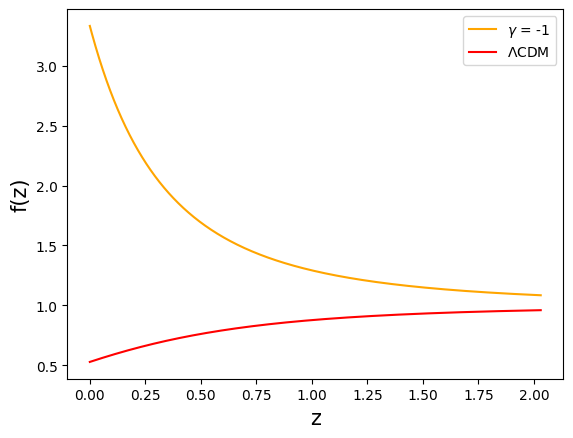

In [45]:
gamma4 = -1

f4 = Om ** gamma4

plt.plot(z, f4, color='orange', label='$\gamma$ = -1')
plt.plot(z, f, color='red', label='$\Lambda$CDM')
plt.xlabel('z', fontsize=15)
plt.ylabel('f(z)', fontsize=15)
plt.legend()
#plt.ylim(0.4, 2)
#plt.savefig('f linder e negative gamma.pdf')
plt.show()

Vamos fazer um teste do processo gaussiano espaçando os dados de $f(z)$.

In [39]:
f_dados = np.array([0.56, 0.49, 0.49, 0.60, 0.70, 0.66, 0.70, 0.75, 0.73, 0.91, 0.90])
f_erro = np.array([0.07+0.09, 0.14+0.08, 0.12-0.07, 0.10+0.15, 0.18-0.1, 0.09-0.05, 0.07-0.02, 0.18-0.07, 0.07+0.14, 0.36+0.24, 0.24+0.17])
z_dados = np.array([0.013, 0.15, 0.18, 0.22, 0.35, 0.38, 0.41, 0.55, 0.60, 0.77, 1.40])

In [20]:
!pip install git+https://github.com/JCGoran/GaPP@feature/python3#GaPP
from gapp import gp
from numpy import loadtxt, savetxt

  Cloning https://github.com/JCGoran/GaPP (to revision feature/python3) to /tmp/pip-req-build-icdxsicp
  Running command git clone --filter=blob:none --quiet https://github.com/JCGoran/GaPP /tmp/pip-req-build-icdxsicp
  Running command git checkout -b feature/python3 --track origin/feature/python3
  Switched to a new branch 'feature/python3'
  Branch 'feature/python3' set up to track remote branch 'feature/python3' from 'origin'.
  Resolved https://github.com/JCGoran/GaPP to commit 931e4d0e0eb861b01c315e960f74b31a9996aa6f
  Preparing metadata (setup.py) ... done
  Created wheel for GaPP: filename=GaPP-1.0-py3-none-any.whl size=63956 sha256=e579958a71fcb7756d2bc255616dd6b987588c62b6ccec2b59ab5307589ca2b4
  Stored in directory: /tmp/pip-ephem-wheel-cache-4y2_dcj1/wheels/ce/00/a9/051978c449722640db18aff4d8599b5b81dd35fc9c096657fe
Successfully built GaPP



Optimized hyperparameters:
theta = [0.66779874 1.28370045]


<ipython-input-42-92c6872ce464>:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r." (-> color='r'). The keyword argument will take precedence.
  plt.errorbar(x_gapp, y_gapp, e, fmt='r.', color='purple', markersize=10, label='Data')


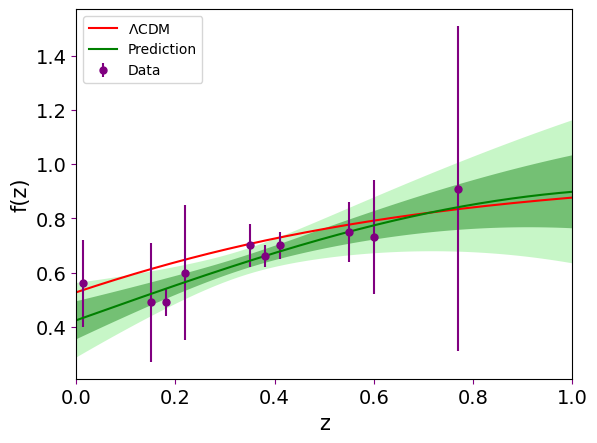

In [42]:
# nomeando
x_gapp = z_dados
y_gapp = f_dados
e = f_erro

# xmin, xmax and nstar are interpreted as two-dimensional vectors
xmin = 0
xmax = 1
nstar = 1000

# initial values of the hyperparameters of the squared-exponential covariance function
initheta = [2.0, 2.0]

# initialization of the Gaussian Process
g = gp.GaussianProcess(x_gapp, y_gapp, e, cXstar=(xmin, xmax, nstar))

# training of the hyperparameters and reconstruction of the function
(rec, theta) = g.gp(theta=initheta)

xi = rec[:, 0]

y_pred = rec[:, 1]
sigma  = rec[:, 2]

y_pred_95_less = y_pred - 1.9600*sigma
y_pred_95_plus = y_pred + 1.9600*sigma

# Plot the function, the prediction and the 95% confidence interval
plt.figure()
plt.tick_params(labelsize=14, color='purple')
plt.plot(z, f, color='red', label='$\Lambda$CDM')
plt.errorbar(x_gapp, y_gapp, e, fmt='r.', color='purple', markersize=10, label='Data')
plt.plot(xi, y_pred, color = 'green', label='Prediction', linestyle="-")
plt.fill(np.concatenate([xi, xi[::-1]]),
         np.concatenate([y_pred - 1.9600 * sigma,
                        (y_pred + 1.9600 * sigma)[::-1]]),
         alpha=.5, color = 'lightgreen', ec='None')
plt.fill(np.concatenate([xi, xi[::-1]]),
         np.concatenate([y_pred - 1 * sigma,
                        (y_pred + 1 * sigma)[::-1]]),
         alpha=.5, color = 'forestgreen', ec='None')

# legenda, label e título
plt.xlabel('z', fontsize=15)
plt.ylabel('f(z)', fontsize=15)
plt.xlim(0,1)
plt.legend(loc='upper left')
#plt.savefig('f_GP_teste2.pdf')
plt.show()